# 0. Imports

In [56]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
import os
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import f1_score, accuracy_score

from wsd.load_data import load_data

from linpub.metrics import accuracy

from lineval.disambiguation_eval_backup import ClusterByMeaningModelv3
from lineval.disambiguation_eval_backup import OpenAiWordSenseComparatorv3, show_plots
from wsd.models import DummyComparator, ClusterByMeaningModel

from etl.models import Candidate

In [58]:
X,y = load_data("fr")
for x in X :
    x.context = x.example
size = 400
X, y = X[:size], y[:size]

In [59]:
openai_api_key = os.getenv('OPEN_AI_API_KEY')
comp = OpenAiWordSenseComparatorv3(openai_api_key,
                                   openai_model='gpt-4o-mini',
                                   thought_process=False)
model1 = ClusterByMeaningModelv3(word_sense_comparator=comp)

In [60]:
dummy2 = DummyComparator(probability=1)
model2 = ClusterByMeaningModel(comparator=dummy2)

dummy3 = DummyComparator(probability=0)
model3 = ClusterByMeaningModel(comparator=dummy3)

# 1. 1st try (raw, model, dataset) (ignore)

In [6]:
#X, y_pred1 = model1.predict(X, verbose=True)
y_pred2 = model2.predict(X, verbose=True)
y_pred3 = model3.predict(X, verbose=True)

100%|██████████| 268/268 [00:00<00:00, 4926.08it/s]


In [8]:
# accuracy(y_pred1, y),
accuracy(y_pred2, y), accuracy(y_pred3, y)

(0.8768656716417911, 0.505)

In [10]:
df = pd.DataFrame(X)
df = df.drop(columns=["context"])
df["pred"] = [c.pred for c in X]
df["process"] = [c.process for c in X]
df['y_pred'] = y_pred1
df['y'] = y
df = df.sort_values(by=["lemma"])
df = df[df["process"] != "lone candidate"]
#reindex
df = df.reset_index(drop=True)
df["same_y"] = df["y"] == df["y"].shift(-1)
df["same_pred"] = df["y_pred"] == df["y_pred"].shift(-1)
df["correct"] = df["same_y"] == df["same_pred"]
df

AttributeError: 'Candidate' object has no attribute 'pred'

In [ ]:
from lineval.disambiguation_eval_backup import show_plots
show_plots(df)

In [ ]:
df = df[(df["correct"] == False) | (df["correct"].shift(1) == False)]
df

In [ ]:

df.to_csv("test.csv", index=False)

# 2. 2nd try : massaged dataset, new metric

## 2.1 load

In [61]:
X,y = load_data("fr")
for x in X :
    x.context = x.example
len(X), len(y)

(24266, 24266)

## 2.1.2 Exploration

Text(0.5, 1.0, 'Number of examples in pos/lemma groups')

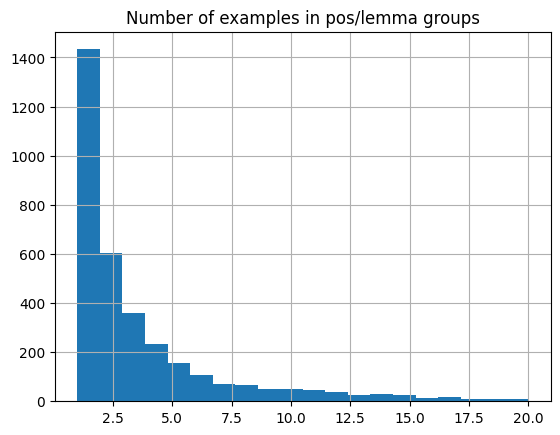

In [62]:
# group by lemma and pos
X_df = pd.DataFrame(X)
X_df["y"] = y
cond = X_df.groupby(["lemma", "pos"]).size() <= 20# show only lemmas with more than 10 examples
X_df_20m = X_df.set_index(["lemma", "pos"]).loc[cond].reset_index()
X_df_20m.groupby(["lemma", "pos"]).size(). hist(bins=20)
plt.title("Number of examples in pos/lemma groups")

Text(0.5, 1.0, 'Number of examples in pos/lemma groups')

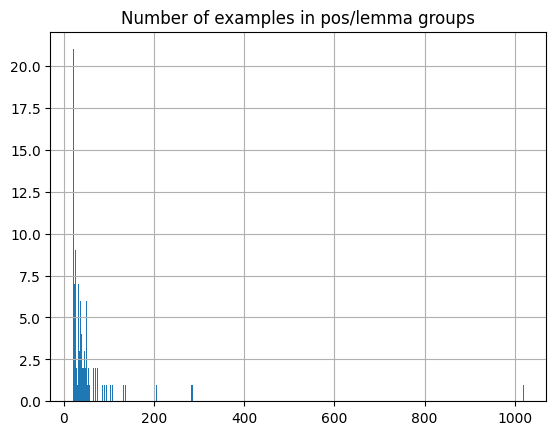

In [63]:
# group by lemma and pos
cond = X_df.groupby(["lemma", "pos"]).size() > 20# show only lemmas with more than 10 examples
X_df_20p = X_df.set_index(["lemma", "pos"]).loc[cond].reset_index()
X_df_20p.groupby(["lemma", "pos"]).size().hist(bins=1020)
plt.title("Number of examples in pos/lemma groups")

In [64]:
X_df.groupby(["lemma", "pos"]).size().sort_values(ascending=False).head(10)

lemma      pos 
dire       VERB    1020
sembler    VERB     343
commencer  VERB     311
voir       VERB     309
savoir     VERB     286
utiliser   VERB     284
penser     VERB     275
vouloir    VERB     218
essayer    VERB     206
homme      NOUN     173
dtype: int64

In [65]:
X_df[X_df["lemma"] == "dire"]["y"].value_counts()

y
bn:00093287v\n    944
bn:00094862v\n     76
Name: count, dtype: int64

In [66]:
lone_cands = len(X_df.groupby(["lemma", "pos"]).filter(lambda x: len(x) == 1))
lone_cands, lone_cands/len(X_df)

(1433, 0.0590538201598945)

## 2.2 Dire (say) vs dire (tell)

In [67]:
X_df[(X_df["lemma"] == "dire") & (X_df["y"] == "bn:00093287v\n")].head(20) #say

,pos,text,lemma,lemma_meaning,example,context,y
131,VERB,dit,dire,NA,"Il a pris le receveur et a dit , "" chef de la ...","Il a pris le receveur et a dit , "" chef de la ...",bn:00093287v\n
148,VERB,dit,dire,NA,""" Alors voilà "" , a -t -il dit .",""" Alors voilà "" , a -t -il dit .",bn:00093287v\n
150,VERB,dit,dire,NA,"Cependant probablement il était , Pauling dit ...","Cependant probablement il était , Pauling dit ...",bn:00093287v\n
161,VERB,dit,dire,NA,Madden a dit qu' il le verrait à deux heures e...,Madden a dit qu' il le verrait à deux heures e...,bn:00093287v\n
311,VERB,dit,dire,NA,"Sur parole charpentier Staffe , qui a dit qu' ...","Sur parole charpentier Staffe , qui a dit qu' ...",bn:00093287v\n
334,VERB,dit,dire,NA,Cook Bennett Mathues a dit que Juet avait préd...,Cook Bennett Mathues a dit que Juet avait préd...,bn:00093287v\n
478,VERB,dit,dire,NA,On ne dit presque rien de victoires spectacula...,On ne dit presque rien de victoires spectacula...,bn:00093287v\n
481,VERB,dit,dire,NA,George Meredith a dit que la ferveur est le cœ...,George Meredith a dit que la ferveur est le cœ...,bn:00093287v\n
642,VERB,dit,dire,NA,Je leur ai dit de beaux mensonges et ils ont t...,Je leur ai dit de beaux mensonges et ils ont t...,bn:00093287v\n
682,VERB,dit,dire,NA,""" S' il vous plaît "" , a -t -elle dit , "" S' i...",""" S' il vous plaît "" , a -t -elle dit , "" S' i...",bn:00093287v\n


In [68]:
X_df[(X_df["lemma"] == "dire") & (X_df["y"] != "bn:00093287v\n")].head(20) #tell

,pos,text,lemma,lemma_meaning,example,context,y
739,VERB,dit,dire,NA,"On nous a dit qu' à Pathet Lao , un Américain ...","On nous a dit qu' à Pathet Lao , un Américain ...",bn:00094862v\n
830,VERB,dire,dire,NA,""" J' ai vraiment quelque chose d' important à ...",""" J' ai vraiment quelque chose d' important à ...",bn:00094862v\n
835,VERB,dit,dire,NA,Elle me l' a dit .,Elle me l' a dit .,bn:00094862v\n
1271,VERB,dit,dire,NA,"Donc tout-important sont des idées , on nous d...","Donc tout-important sont des idées , on nous d...",bn:00094862v\n
1346,VERB,dit,dire,NA,"L'homme , on nous dit , est doué de raison et ...","L'homme , on nous dit , est doué de raison et ...",bn:00094862v\n
1735,VERB,dis,dire,NA,""" Je te le dis , tu veux laisser ça comme ça ,...",""" Je te le dis , tu veux laisser ça comme ça ,...",bn:00094862v\n
1854,VERB,dit,dire,NA,"Mais c' était un signe d' espoir , il s' est d...","Mais c' était un signe d' espoir , il s' est d...",bn:00094862v\n
2427,VERB,dit,dire,NA,L' énormité de ce que Conrad lui avait dit a r...,L' énormité de ce que Conrad lui avait dit a r...,bn:00094862v\n
2431,VERB,dit,dire,NA,Il savait que Conrad lui avait dit la vérité .,Il savait que Conrad lui avait dit la vérité .,bn:00094862v\n
2524,VERB,dit,dire,NA,"Elle n' a rien dit à personne , même à sa mère...","Elle n' a rien dit à personne , même à sa mère...",bn:00094862v\n


## 2.3 Creating a balanded set

In [69]:
# X_df_len3 = X_df.groupby(["lemma", "pos"]).filter(lambda x: len(x) == 3)
# X_df_bl_kinda = pd.DataFrame()
# for name, group in X_df_len3.groupby(["lemma", "pos"]):
#     if group["y"].nunique() == 2:
#         X_df_bl_kinda = pd.concat([X_df_bl_kinda, group])
# len(X_df_bl_kinda)

### Kind of a balanced dataset
-----

The set will be balanced, but the current model will have different predictions based on the order of elements.

#### Example:

#### Sequence: `meaning_a / meaning_b / meaning_a` (`a / b / a`)

##### Predictions:
1. **Sequence:** `a / b / a`
   - `a / a` (ref)
   - `b / a` (0): No more meaning to check -> New meaning created
   - `a / a` (1): Matched!
   - **API Calls:** 2

2. **Sequence:** `b / a / a`
   - `b / b` (ref)
   - `a / b` (0): No more meaning to check -> New meaning created
   - `a / b` (0)
   - `a / a` (1): Matched!
   - **API Calls:** 3

3. **Sequence:** `a / a / b`
   - `a / a` (ref)
   - `a / a` (1): Matched!
   - `a / b` (0)
   - `a / b` (0)
   - **API Calls:** 3

For full balance, control the order: `a / b / a`

-----

In [70]:
def get_balanced_df(X,y):
    X_df = pd.DataFrame(X)
    X_df["context"] = [c.example for c in X]
    X_df = X_df.drop(columns=["example"])
    X_df["y"] = y
    X_df_len3 = X_df.groupby(["lemma", "pos"]).filter(lambda x: len(x) == 3)
    X_df_bl = pd.DataFrame()
    for _, group in X_df_len3.groupby(["lemma", "pos"]):
        if group["y"].nunique() == 2:
            #sort group by number of similar meanings
            group["count"] = group["y"].map(group["y"].value_counts())
            group = group.sort_values(by="count")
            # order will now be b/a/a or a/b/b so  we just permute the first two
            group = pd.concat([group.iloc[[1]], group.iloc[[0]], group.iloc[[2]]])
            X_df_bl = pd.concat([X_df_bl, group])
    X_df_bl = X_df_bl.reset_index(drop=True)
    return X_df_bl
X,y = load_data("fr")
X_df_bl = get_balanced_df(X,y)

## 2.4 Running

In [71]:
def get_balanced_X_y(X_df_bl):
    bl_y = X_df_bl["y"].to_list()
    cand_df = X_df_bl.drop(columns=["y", "count"])
    bl_X = [Candidate(**row) for row in cand_df.to_dict(orient="records")]
    return bl_X, bl_y

bl_X, bl_y = get_balanced_X_y(X_df_bl)
len(bl_X), len(bl_y)

(210, 210)

In [72]:
len(bl_X), len(bl_y)

(210, 210)

In [129]:
#if there is a csv file with the results, load it
if os.path.exists("results.csv"):
    df = pd.read_csv("results.csv")
    y_pred1 = df["y_pred"].to_list()
    process_lst = df["process"].to_list()
    pred_lst = df["pred"].to_list()
    df.drop(columns=["y_pred","process","pred"], inplace=True)
    X = [Candidate(**row) for row in df.to_dict(orient="records")]
    df = pd.DataFrame(bl_X)
    df["process"] = process_lst
    df["pred"] = pred_lst
else:
    X, y_pred1 = model1.predict(bl_X, verbose=True)
    df["y_pred"] = y_pred1
    df["pred"] = [c.pred for c in bl_X]
    process_list = []
    for c in bl_X:
        if not hasattr(c, "process"):
            process_list.append("NA")
        else :
            process_list.append(c.process)
    df["process"] = process_list
    df.to_csv("results.csv", index=False)

y_pred2 = model2.predict(bl_X, verbose=True)
y_pred3 = model3.predict(bl_X, verbose=True)

100%|██████████| 70/70 [00:00<00:00, 2293.58it/s]


In [121]:
# df = pd.read_csv("results.csv")
# df["pred"] = [c.pred for c in bl_X]
# process_list = []
# for c in bl_X:
#     if not hasattr(c, "process"):
#         process_list.append("NA")
#     else :
#         process_list.append(c.process)
# df["process"] = process_list
# df.to_csv("results.csv", index=False)


In [122]:
accuracy(y_pred1, bl_y),accuracy(y_pred2, bl_y), accuracy(y_pred3, bl_y)

(0.1585365853658537, 0.0, 0.33333333333333337)

In [123]:
bl_y[0], y_pred1[0], y_pred2[0], y_pred3[0]

('bn:00052763n\n',
 -7696156640969615163,
 -7696156640969615163,
 -5586873267851984866)

In [134]:
# adjusting y and y_pred for f1 score
X_df = df
X_df_bl["y"] = bl_y
X_df_bl["y_pred"] = y_pred1
f1_y = []
f1_y_pred = []
for _, group in X_df_bl.groupby(["lemma", "pos"]):
    pred1 = group["y_pred"].iloc[1] == group["y_pred"].iloc[0]
    pred2 = group["y_pred"].iloc[2] == group["y_pred"].iloc[0]
    group["y"] = pd.Series(["ref", False, True])
    group["y_pred"] = pd.Series(["ref", pred1, pred2])
    f1_y.extend([False, True])
    f1_y_pred.extend([pred1, pred2])
len(f1_y), len(f1_y_pred), 210*2/3

(140, 140, 140.0)

In [135]:
def get_f1_score(df, bl_y, y_pred):
    X_df = df
    X_df["y"] = bl_y
    X_df["y_pred"] = y_pred
    f1_y = []
    f1_y_pred = []
    for _, group in X_df.groupby(["lemma", "pos"]):
        pred1 = bool(group["y_pred"].iloc[1] == group["y_pred"].iloc[0])
        pred2 = bool(group["y_pred"].iloc[2] == group["y_pred"].iloc[0])
        # group["y"] = pd.Series(["ref", False, True])
        # group["y_pred"] = pd.Series(["ref", pred1, pred2])
        f1_y.extend([False, True])
        f1_y_pred.extend([pred1, pred2])
    return f1_score(f1_y, f1_y_pred) , accuracy_score(f1_y, f1_y_pred)

In [137]:
get_f1_score(df, bl_y, y_pred1), get_f1_score(df, bl_y, y_pred2), get_f1_score(df, bl_y, y_pred3)
print(f"--f1 scores--")
print(f"Model: {get_f1_score(df, bl_y, y_pred1)[0]}")
print(f"Dummy(1): {get_f1_score(df, bl_y, y_pred2)[0]}")
print(f"Dummy(0): {get_f1_score(df, bl_y, y_pred3)[0]}")
print(f"--sklearn accuracy scores--")
print(f"Model: {get_f1_score(df, bl_y, y_pred1)[1]}")
print(f"Dummy(1): {get_f1_score(df, bl_y, y_pred2)[0]}")
print(f"Dummy(0): {get_f1_score(df, bl_y, y_pred3)[1]}")
print(f"--linpub accuracy scores--")
print(f"Model: {accuracy(y_pred1, bl_y)}")
print(f"Dummy(1): {accuracy(y_pred2, bl_y)}")
print(f"Dummy(0): {accuracy(y_pred3, bl_y)}")

--f1 scores--
Model: 0.6598984771573604
Dummy(1): 0.6666666666666666
Dummy(0): 0.0
--sklearn accuracy scores--
Model: 0.5214285714285715
Dummy(1): 0.6666666666666666
Dummy(0): 0.5
--linpub accuracy scores--
Model: 0.1585365853658537
Dummy(1): 0.0
Dummy(0): 0.33333333333333337


# plotting

In [140]:
plot_df = df
plot_df["y_pred"] = y_pred1
plot_df["y"] = bl_y
plot_df.drop(columns=["text_meaning", "text_romaji", "text_hiragana", "lemma_romaji", "lemma_hiragana", "example", "annotation","document", "status", ], inplace=True)
correct_df = pd.DataFrame()
for _, gp in plot_df.groupby(["lemma", "pos"]):
    pred1 = gp["y_pred"].iloc[1] != gp["y_pred"].iloc[0]
    pred2 = gp["y_pred"].iloc[2] == gp["y_pred"].iloc[0]
    gp = gp.copy()  # To avoid SettingWithCopyWarning
    gp["correct"] = pd.Series(["ref", pred1, pred2], index=gp.index)
    correct_df = pd.concat([correct_df, gp])
correct_df.head(20)

,id,lang,pos,text,lemma,lemma_meaning,context,process,pred,y,y_pred,correct
0,NA,NA,NOUN,Mississippi,Mississippi,1,"Un soldat de Mississippi a écrit: "" Notre géné...",NaN,1.00,bn:00052763n\n,-7696156640969615163,ref
1,NA,NA,NOUN,Mississippi,Mississippi,2,Raymond Vernon rapporte que les résidents de l...,NaN,1.00,bn:00055331n\n,-7696156640969615163,False
2,NA,NA,NOUN,Mississippi,Mississippi,3,Mais en regardant Faulkner dans son arrière-pl...,NaN,0.90,bn:00052763n\n,-7696156640969615163,True
3,NA,NA,NOUN,abandon,abandon,1,"Je proposerais , d' abord , un abandon de tent...",NaN,1.00,bn:00000212n\n,2586867517488041851,ref
4,NA,NA,NOUN,abandon,abandon,2,"Que cet abandon ait lieu sur une scène , à cou...",NaN,0.90,bn:00000213n\n,2586867517488041851,False
5,NA,NA,NOUN,abandon,abandon,3,Pendant un certain temps après l' abandon de l...,NaN,0.90,bn:00000212n\n,2586867517488041851,True
6,NA,NA,NOUN,absorption,absorption,1,L' absorption par résonance magnétique a été d...,NaN,1.00,bn:00000472n\n,8212390763614078809,ref
7,NA,NA,NOUN,absorption,absorption,2,Un test de Schilling a démontré une absorption...,NaN,0.90,bn:00000471n\n,8212390763614078809,False
8,NA,NA,NOUN,absorption,absorption,3,Comme l' absorption de ondes radio dans un mat...,NaN,0.90,bn:00000472n\n,8212390763614078809,True
9,NA,NA,NOUN,administrateur,administrateur,1,"Si un contribuable décède , l' exécuteur testa...",NaN,1.00,bn:00001435n\n,-5671038035386517389,ref


In [141]:
correct_df[correct_df["correct"] == False]["pred"].value_counts(), correct_df[correct_df["correct"] == True]["pred"].value_counts()

(pred
 0.90    37
 0.80     9
 0.95     5
 1.00     4
 0.85     4
 0.70     3
 0.10     2
 0.20     1
 0.60     1
 0.30     1
 Name: count, dtype: int64,
 pred
 0.90    41
 0.95    11
 0.10     4
 0.85     4
 0.20     3
 0.70     3
 0.80     3
 1.00     3
 0.30     1
 Name: count, dtype: int64)

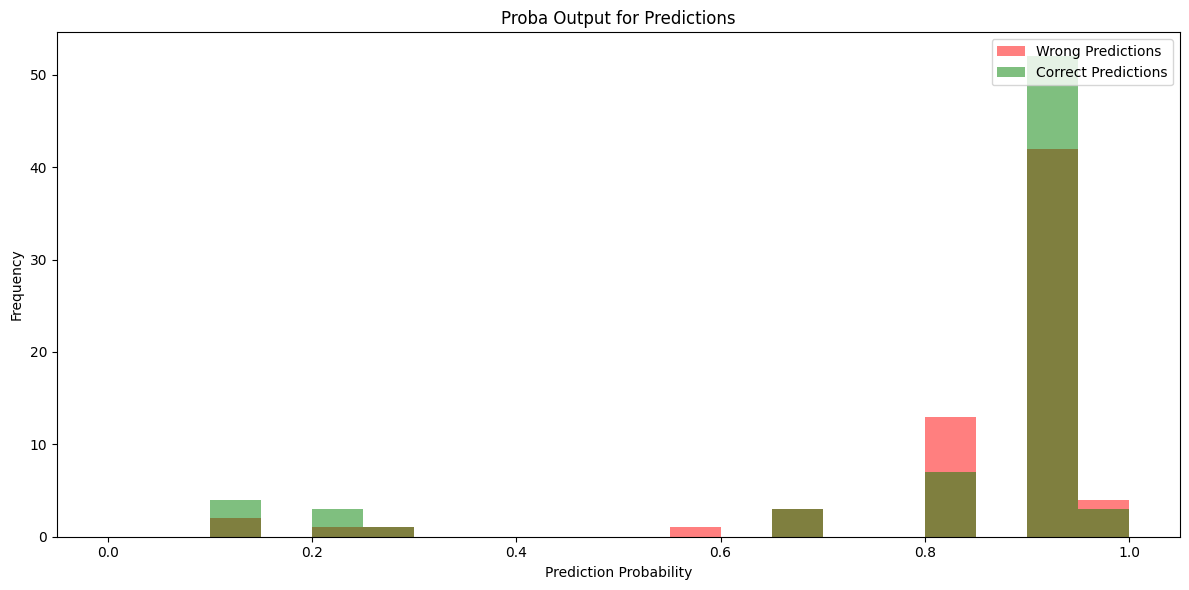

In [142]:
show_plots(correct_df)

# Conclusions


-------
1. base mdel and data

1.1 The dummy 1 is better that the model at 91% vs 90%

1.2 The dataset is unbalanced

1.3 The model errors seem to be due to errors in the y

-------
2. balancing the dataset

2.1. There are 1433 lone candidates, ~6% of the dataset

2.2 The top pos/lemma group is dire, with 1020 rows (2 different meanings)(944of the main maining, and then 74 of the 2nd) (say vs tell)

2.3 From the pos/lemma groups with 3 rows and 2 meanings, (210 rows) I made a balanced, ordered dataset where the model will have to do 2 outputs: 0 then 1 

2.4. The model is barely better than the baseline